# Fig 2: average insula HGA, NMF traces, hard-label HGA, rank, PCA, and insula map

Separate figures, not a combined panel:

1. Mean insula **HGA** across assigned electrodes (pooled, before NMF)
2. Canonical concat-NMF **normalized H** (`H_by_phase.csv`)
3. Packaged **hard-label HGA** mean ± CI
4. Hard-label HGA **heatmap** (rows = assigned electrodes)
5. Concat-NMF **cosine silhouette** vs *k* (`rank_selection_metrics.csv`; *k*=2–6)
6. PC1–PC2 scatter colored by k-means *k*=3 (`pc_scores.csv`; Hungarian-matched to NMF names)
6b. Dominance histogram (stacked by hard label) and mixed count
7. Static insula map: hard-label contacts + mixed overlays + KDE on non-mixed
8. Cluster × Hammers pies
9. Laterality sketch: assigned L/R counts vs implant-corrected cluster rate

Cluster names and colors come from `FUNCTION_COLORS` / `CLUSTER_LABELS`.


In [5]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr
from mne_bids import BIDSPath
from tqdm import tqdm

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.nmf.waveform_analysis import CLUSTER_LABELS, CLUSTER_ORDER, FUNCTION_COLORS, ordered_clusters

from src.paths import (
    hga_results_dir,
    img_dir,
    nmf_assignments_path,
    nmf_results_dir,
    save_svg,
)

In [6]:
from matplotlib import font_manager
import pathlib

for _ttf in (pathlib.Path(sys.prefix) / "fonts").glob("arial*.ttf"):
    font_manager.fontManager.addfont(str(_ttf))

cm = 1 / 2.54
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]

fontsize = 7
fontdict = dict(fontsize=fontsize)

CLUSTERS = list(CLUSTER_ORDER)
HUE_ORDER = [CLUSTER_LABELS[c] for c in CLUSTERS]
PALETTE = [FUNCTION_COLORS[c] for c in CLUSTERS]
CLUSTER_CMAPS = {
    name: sns.light_palette(color, as_cmap=True)
    for name, color in FUNCTION_COLORS.items()
}
LOADING_COLS = [f"loading_{name}" for name in CLUSTERS]
MIXED_SPECIFICITY_MAX = 0.20
MIXED_COLOR = "#6E6E6E"
# Two-way mix: winner − runner-up = 0.20 ⇒ dominance = 0.60.
MIXED_DOMINANCE_REF = 0.5 * (1.0 + MIXED_SPECIFICITY_MAX)


def specificity_from_loadings(loadings: np.ndarray):
    """s_k = max(p_k − max_{j≠k} p_j, 0) with p = loading / sum."""
    loadings = np.clip(np.asarray(loadings, dtype=float), 0.0, None)
    total = loadings.sum(axis=1, keepdims=True)
    proportion = np.divide(
        loadings, total, out=np.zeros_like(loadings), where=total > 0
    )
    spec = np.zeros_like(proportion)
    for k in range(proportion.shape[1]):
        other = np.delete(proportion, k, axis=1)
        spec[:, k] = np.clip(proportion[:, k] - other.max(axis=1), 0.0, None)
    return proportion, spec


def annotate_mixed_assignments(df: pd.DataFrame) -> pd.DataFrame:
    missing = [col for col in LOADING_COLS if col not in df.columns]
    if missing:
        raise KeyError(f"assignments missing {missing}")
    out = df.copy()
    _, spec = specificity_from_loadings(out[LOADING_COLS].to_numpy())
    out["specificity_max"] = spec.max(axis=1)
    out["is_mixed"] = out["specificity_max"] < MIXED_SPECIFICITY_MAX
    return out

TASKS = [
    "PhonemeSequence",
    "LexicalDelay",
    "PictureNaming",
    "SentenceRep",
]
PHASES = ["stimulus", "delay", "go", "response"]
DESCRIPTION = "Repeat"
MODALITY = "sound"
EXCLUDE_SUBJECTS = {"D0121"}

NMF_DIR = nmf_results_dir()
NMF_ASSIGNMENTS = nmf_assignments_path()
IMG_DIR = img_dir("fig2")

# Shared canvas so HGA traces and heatmap columns (especially t=0) align in Illustrator.
FIG2_WIDTH = 3 * len(PHASES) * cm
FIG2_XLIM = (-1.0, 1.0)
FIG2_XTICKS = (-1.0, 0.0, 1.0)
FIG2_MARGINS = dict(left=0.16, right=0.94, wspace=0.2)

# Average / hard-label traces / heatmap: no go column.
TRACE_PHASES = ["stimulus", "delay", "response"]
FIG2_TRACE_SIZE = (8 * cm, 3 * cm)
FIG2_TRACE_XLIMS = {
    "stimulus": (-0.5, 0.6),
    "delay": (0.0, 1.0),
    "response": (-0.5, 1.5),
}
FIG2_TRACE_XTICKS = {
    "stimulus": (-0.5, 0.0, 0.6),
    "delay": (0.0, 1.0),
    "response": (-0.5, 0.0, 1.5),
}


def save_aligned_svg(fig, name: str) -> pathlib.Path:
    """Save at the figure canvas size (no tight crop) so panels share x positions."""
    path = IMG_DIR / name
    fig.savefig(path, format="svg", bbox_inches=None, pad_inches=0)
    return path


## Load assignments and packaged HGA


In [7]:
assignments = pd.read_csv(NMF_ASSIGNMENTS)
assign_map = assignments.set_index("channel")["functional_cluster"]
keep_channels = set(assignments["channel"])

hga_paths = []
for task in TASKS:
    hga_paths.extend(
        BIDSPath(
            root=str(hga_results_dir(task)),
            datatype="HGA",
            suffix="time",
            check=False,
        ).match()
    )

frames = []
for path in tqdm(hga_paths, desc="load HGA"):
    df = pd.read_csv(path)
    if "channel" not in df.columns:
        continue
    df = df[df["channel"].isin(keep_channels)]
    if not df.empty:
        frames.append(df)

if not frames:
    raise FileNotFoundError(
        f"No HGA rows for NMF channels under results/hga/ for tasks={TASKS}"
    )

HGAs = pd.concat(frames, ignore_index=True)
HGAs.loc[HGAs.phase == "Resp", "phase"] = "Response"
HGAs.loc[HGAs.phase == "Audio", "phase"] = "Stimulus"
HGAs["phase"] = HGAs["phase"].astype(str).str.lower()
HGAs["functional_cluster"] = HGAs["channel"].map(assign_map)

subset = HGAs[
    (HGAs.description == DESCRIPTION)
    & (HGAs.modality == MODALITY)
    & HGAs["functional_cluster"].isin(CLUSTERS)
    & ~HGAs["subject"].isin(EXCLUDE_SUBJECTS)
].copy()
subset["cluster_label"] = subset["functional_cluster"].map(CLUSTER_LABELS)

print("assignments:", NMF_ASSIGNMENTS)
print("assignment clusters:", assignments["functional_cluster"].value_counts().to_dict())
print(subset.groupby("functional_cluster")["channel"].nunique())
print("phases:", sorted(subset.phase.unique()))
print("tasks:", sorted(subset.task.unique()) if "task" in subset.columns else "n/a")
if subset.empty:
    raise ValueError(
        "Hard-label HGA subset is empty. Check cluster names, description, and modality."
    )

load HGA: 100%|██████████| 1834/1834 [06:38<00:00,  4.60it/s]


assignments: /hpc/group/coganlab/nanlinshi/insula-functional/results/nmf/channel_assignments.csv
assignment clusters: {'motor': 136, 'sustain': 80, 'sensory': 39}
functional_cluster
motor      136
sensory     39
sustain     80
Name: channel, dtype: int64
phases: ['delay', 'go', 'response', 'stimulus']
tasks: ['LexicalDelay', 'PhonemeSequence', 'PictureNaming', 'SentenceRep']


## 1. Average insula HGA

Mean high-gamma across all NMF-assigned insula electrodes, pooled
(not split by cluster). Stimulus / delay / response only (no go).
Same canvas, column widths, and y scale as the hard-label traces.

Seaborn lineplot shows mean ± 95% CI.


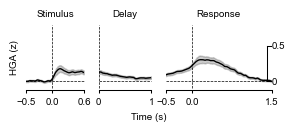

In [8]:
# Pooled insula mean. Same canvas / column widths as hard-label traces. No go.
width_ratios = [hi - lo for lo, hi in (FIG2_TRACE_XLIMS[p] for p in TRACE_PHASES)]
fig = plt.figure(figsize=FIG2_TRACE_SIZE)
gs = fig.add_gridspec(
    nrows=1,
    ncols=len(TRACE_PHASES),
    width_ratios=width_ratios,
    wspace=FIG2_MARGINS["wspace"],
    left=FIG2_MARGINS["left"],
    right=FIG2_MARGINS["right"],
    bottom=0.28,
    top=0.82,
)
axes = [fig.add_subplot(gs[0, j]) for j in range(len(TRACE_PHASES))]

for ax, phase in zip(axes, TRACE_PHASES):
    lo, hi = FIG2_TRACE_XLIMS[phase]
    phase_df = subset[
        (subset.phase == phase) & (subset.time >= lo) & (subset.time <= hi)
    ]
    sns.lineplot(
        data=phase_df,
        x="time",
        y="value",
        ax=ax,
        color="k",
        legend=False,
        lw=1,
    )
    ax.set_xlim(lo, hi)
    ax.set_xticks(FIG2_TRACE_XTICKS[phase])
    ax.set_xlabel("")
    ax.set_title(phase.capitalize(), fontsize=fontsize)

for ax in axes:
    ax.axvline(x=0, color="k", linestyle="--", linewidth=0.5, clip_on=False)
    ax.axhline(y=0, color="k", linestyle="--", linewidth=0.5, clip_on=False)
    ax.tick_params(labelsize=fontsize, width=0.75, length=2, which="both")
    plt.setp(ax.spines.values(), linewidth=0.75)
    sns.despine(ax=ax, offset=1, trim=True)
    ax.set_yticklabels([])
    ax.set_yticks([])
    ax.spines["left"].set_visible(False)
    ax.set_ylim(-0.1, 0.8)
    ax.set_ylabel("HGA (z)" if ax is axes[0] else "", fontsize=fontsize)

scale = 0.5
ax = axes[-1]
xmin, xmax = ax.get_xlim()
x_span = xmax - xmin
x_bar = xmax - 0.04 * x_span
cap = 0.03 * x_span
ax.plot([x_bar, x_bar], [0.0, scale], color="k", lw=0.75, clip_on=False)
ax.plot([x_bar, x_bar + cap], [0.0, 0.0], color="k", lw=0.75, clip_on=False)
ax.plot([x_bar, x_bar + cap], [scale, scale], color="k", lw=0.75, clip_on=False)
ax.text(x_bar + 1.4 * cap, 0.0, "0", fontsize=fontsize, va="center", ha="left")
ax.text(x_bar + 1.4 * cap, scale, "0.5", fontsize=fontsize, va="center", ha="left")

xmid = 0.5 * (FIG2_MARGINS["left"] + FIG2_MARGINS["right"])
fig.text(xmid, 0.08, "Time (s)", ha="center", va="top", fontsize=fontsize)

save_aligned_svg(fig, "fig2_insula_average_traces.svg")
plt.show()


## 2. NMF traces (normalized H)

Canonical concat-NMF basis waveforms. One curve per cluster, not electrode HGA.


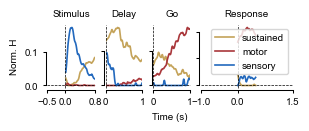

In [9]:
H_by_phase = pd.read_csv(NMF_DIR / "H_by_phase.csv")
H_by_phase = H_by_phase[H_by_phase["functional_cluster"].isin(CLUSTERS)].copy()
H_by_phase["cluster_label"] = H_by_phase["functional_cluster"].map(CLUSTER_LABELS)
H_by_phase["phase"] = pd.Categorical(
    H_by_phase["phase"], categories=PHASES, ordered=True
)

# Concat-NMF H is post-onset only (no pre-event samples). Go cannot use the
# HGA crop (-1, 0); that window is empty. Keep the same column *width* as HGA go.
FIG2_PHASE_XLIMS = {
    "stimulus": (-0.5, 0.8),
    "delay": (0.0, 1.0),
    "go": (0.0, 1.0),
    "response": (-1.0, 1.5),
}
FIG2_PHASE_XTICKS = {
    "stimulus": (-0.5, 0.0, 0.8),
    "delay": (0.0, 1.0),
    "go": (0.0, 1.0),
    "response": (-1.0, 0.0, 1.5),
}

width_ratios = [hi - lo for lo, hi in (FIG2_PHASE_XLIMS[p] for p in PHASES)]
fig = plt.figure(figsize=(8 * cm, 3 * cm))
gs = fig.add_gridspec(
    nrows=1,
    ncols=len(PHASES),
    width_ratios=width_ratios,
    wspace=FIG2_MARGINS["wspace"],
    left=FIG2_MARGINS["left"],
    right=FIG2_MARGINS["right"],
    bottom=0.28,
    top=0.82,
)
axes = [fig.add_subplot(gs[0, j]) for j in range(len(PHASES))]

for ax, phase in zip(axes, PHASES):
    lo, hi = FIG2_PHASE_XLIMS[phase]
    phase_df = H_by_phase[
        (H_by_phase["phase"] == phase)
        & (H_by_phase["time"] >= lo)
        & (H_by_phase["time"] <= hi)
    ]
    sns.lineplot(
        data=phase_df,
        x="time",
        y="normalized_H",
        hue="cluster_label",
        hue_order=HUE_ORDER,
        ax=ax,
        palette=PALETTE,
        legend=ax is axes[-1],
        lw=1.2,
        errorbar=None,
    )
    ax.set_xlim(lo, hi)
    ax.set_xticks(FIG2_PHASE_XTICKS[phase])
    ax.set_xlabel("")
    ax.set_title(phase.capitalize(), fontsize=fontsize)

for ax in axes:
    ax.axvline(x=0, color="k", linestyle="--", linewidth=0.5, clip_on=False)
    ax.axhline(y=0, color="k", linestyle="--", linewidth=0.5, clip_on=False)
    ax.tick_params(labelsize=fontsize, width=0.75, length=2, which="both")
    plt.setp(ax.spines.values(), linewidth=0.75)
    sns.despine(ax=ax, offset=1, trim=True)
    if ax is axes[-1] and ax.get_legend() is not None:
        ax.legend(title="", fontsize=fontsize)
    else:
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()
    if ax is not axes[0]:
        ax.set_yticklabels([])
    ax.set_ylabel("Norm. H" if ax is axes[0] else "", fontsize=fontsize)

xmid = 0.5 * (FIG2_MARGINS["left"] + FIG2_MARGINS["right"])
fig.text(xmid, 0.08, "Time (s)", ha="center", va="top", fontsize=fontsize)

save_aligned_svg(fig, "fig2_nmf_traces.svg")
plt.show()


## 3. Hard-label HGA traces

Electrode HGA (`value`) after hard assignment to sustain / motor / sensory.
Seaborn lineplot shows mean ± 95% CI across assigned electrodes.

Stimulus / delay / response only (no go). Same canvas, column widths,
and y scale as the pooled average traces. Shared x label Time (s).


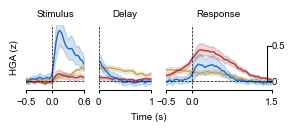

In [10]:
# Same canvas / column widths as the pooled average traces. No go.
width_ratios = [hi - lo for lo, hi in (FIG2_TRACE_XLIMS[p] for p in TRACE_PHASES)]
fig = plt.figure(figsize=FIG2_TRACE_SIZE)
gs = fig.add_gridspec(
    nrows=1,
    ncols=len(TRACE_PHASES),
    width_ratios=width_ratios,
    wspace=FIG2_MARGINS["wspace"],
    left=FIG2_MARGINS["left"],
    right=FIG2_MARGINS["right"],
    bottom=0.28,
    top=0.82,
)
axes = [fig.add_subplot(gs[0, j]) for j in range(len(TRACE_PHASES))]

for ax, phase in zip(axes, TRACE_PHASES):
    lo, hi = FIG2_TRACE_XLIMS[phase]
    phase_df = subset[
        (subset.phase == phase) & (subset.time >= lo) & (subset.time <= hi)
    ]
    sns.lineplot(
        data=phase_df,
        x="time",
        y="value",
        hue="cluster_label",
        hue_order=HUE_ORDER,
        ax=ax,
        palette=PALETTE,
        legend=False,
        lw=1,
    )
    ax.set_xlim(lo, hi)
    ax.set_xticks(FIG2_TRACE_XTICKS[phase])
    ax.set_xlabel("")
    ax.set_title(phase.capitalize(), fontsize=fontsize)

for ax in axes:
    ax.axvline(x=0, color="k", linestyle="--", linewidth=0.5, clip_on=False)
    ax.axhline(y=0, color="k", linestyle="--", linewidth=0.5, clip_on=False)
    ax.tick_params(labelsize=fontsize, width=0.75, length=2, which="both")
    plt.setp(ax.spines.values(), linewidth=0.75)
    sns.despine(ax=ax, offset=1, trim=True)
    ax.set_yticklabels([])
    ax.set_yticks([])
    ax.spines["left"].set_visible(False)
    ax.set_ylim(-0.1, 0.8)
    ax.set_ylabel("HGA (z)" if ax is axes[0] else "", fontsize=fontsize)

scale = 0.5
ax = axes[-1]
xmin, xmax = ax.get_xlim()
x_span = xmax - xmin
x_bar = xmax - 0.04 * x_span
cap = 0.03 * x_span
ax.plot([x_bar, x_bar], [0.0, scale], color="k", lw=0.75, clip_on=False)
ax.plot([x_bar, x_bar + cap], [0.0, 0.0], color="k", lw=0.75, clip_on=False)
ax.plot([x_bar, x_bar + cap], [scale, scale], color="k", lw=0.75, clip_on=False)
ax.text(x_bar + 1.4 * cap, 0.0, "0", fontsize=fontsize, va="center", ha="left")
ax.text(x_bar + 1.4 * cap, scale, "0.5", fontsize=fontsize, va="center", ha="left")

xmid = 0.5 * (FIG2_MARGINS["left"] + FIG2_MARGINS["right"])
fig.text(xmid, 0.08, "Time (s)", ha="center", va="top", fontsize=fontsize)

save_aligned_svg(fig, "fig2_hga_traces.svg")
plt.show()

## 4. Hard-label HGA heatmap

Rows = NMF-union electrodes in each cluster, sorted by first significant time.
Stimulus / delay / response only (no go); column widths match the traces.
Colors are `sns.light_palette` of `FUNCTION_COLORS` (sensory / sustain / motor).
Non-significant timepoints (`mask` False) are blanked.
Shared x label: Time (s).


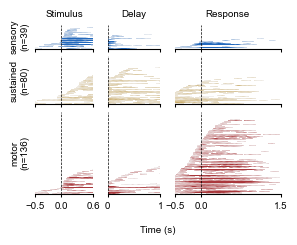

In [11]:
agg = (
    subset.groupby(["channel", "time", "phase", "functional_cluster"], as_index=False)
    .agg(value=("value", "mean"), mask=("mask", "any"))
)
agg.loc[~agg["mask"], "value"] = np.nan

# Heatmap row order: sensory → sustain → motor
HEATMAP_CLUSTERS = ["sensory", "sustain", "motor"]

n_by_cluster = {
    c: int(subset.loc[subset.functional_cluster == c, "channel"].nunique())
    for c in HEATMAP_CLUSTERS
}
height_ratios = [max(n_by_cluster[c], 1) for c in HEATMAP_CLUSTERS]

# Crop to TRACE_PHASES; column widths match the traces.
def cluster_phase_channel_order_crop(
    agg: pd.DataFrame, phase: str, cluster: str
) -> list[str]:
    """Union channels for this cluster, sorted by first significant time in crop."""
    lo, hi = FIG2_TRACE_XLIMS[phase]
    phase_data = agg[
        (agg.phase == phase)
        & (agg.functional_cluster == cluster)
        & (agg.time >= lo)
        & (agg.time <= hi)
    ]
    channels = sorted(phase_data["channel"].unique())
    first_sig = []
    for ch in channels:
        ch_data = phase_data[phase_data.channel == ch]
        sig_times = ch_data.loc[ch_data["mask"], "time"].to_numpy()
        first_sig.append((ch, float(sig_times.min()) if len(sig_times) else np.inf))
    return [ch for ch, _ in sorted(first_sig, key=lambda x: x[1])]


width_ratios = [hi - lo for lo, hi in (FIG2_TRACE_XLIMS[p] for p in TRACE_PHASES)]

fig = plt.figure(
    figsize=(8 * cm, 0.02 * sum(height_ratios) * cm + 0.7 * cm),
)
gs = fig.add_gridspec(
    nrows=len(HEATMAP_CLUSTERS),
    ncols=len(TRACE_PHASES),
    height_ratios=height_ratios,
    width_ratios=width_ratios,
    hspace=0.15,
    wspace=FIG2_MARGINS["wspace"],
    left=FIG2_MARGINS["left"],
    right=FIG2_MARGINS["right"],
    bottom=0.18,
    top=0.92,
)
axes = np.empty((len(HEATMAP_CLUSTERS), len(TRACE_PHASES)), dtype=object)
for i in range(len(HEATMAP_CLUSTERS)):
    for j in range(len(TRACE_PHASES)):
        sharex = axes[0, j] if i > 0 else None
        axes[i, j] = fig.add_subplot(gs[i, j], sharex=sharex)

for i, cluster in enumerate(HEATMAP_CLUSTERS):
    cmap = CLUSTER_CMAPS[cluster]
    for j, phase in enumerate(TRACE_PHASES):
        ax = axes[i, j]
        lo, hi = FIG2_TRACE_XLIMS[phase]
        ordered = cluster_phase_channel_order_crop(agg, phase, cluster)
        phase_data = agg[
            (agg.phase == phase)
            & (agg.functional_cluster == cluster)
            & agg.channel.isin(ordered)
            & (agg.time >= lo)
            & (agg.time <= hi)
        ]

        if not ordered:
            ax.text(
                0.5, 0.5, "No channels",
                ha="center", va="center", transform=ax.transAxes, fontsize=fontsize,
            )
        else:
            pivot = (
                phase_data.pivot(index="channel", columns="time", values="value")
                .reindex(index=ordered)
            )
            da = xr.DataArray(
                pivot.to_numpy(dtype=float),
                coords={"channel": pivot.index, "time": pivot.columns.astype(float)},
                dims=["channel", "time"],
            )
            time_values = da.coords["time"].values.astype(float)
            step = np.diff(time_values).mean() if len(time_values) > 1 else 0.01
            time_edges = np.concatenate(
                (
                    [time_values[0] - step / 2],
                    time_values[:-1] + step / 2,
                    [time_values[-1] + step / 2],
                )
            )
            channel_edges = np.arange(len(ordered) + 1)
            T, C = np.meshgrid(time_edges, channel_edges)

            ax.pcolormesh(
                T, C, da.values, cmap=cmap, vmin=0, vmax=1,
                shading="auto", rasterized=True,
            )

        ax.axvline(x=0, color="k", linestyle="--", linewidth=0.5, clip_on=False)
        ax.set_xlim(lo, hi)
        ax.set_ylim(0, max(len(ordered), 1))
        ax.set_yticks([])
        ax.tick_params(axis="y", which="both", left=False, right=False, labelleft=False)
        sns.despine(ax=ax, offset=0, trim=False)
        ax.spines["left"].set_visible(False)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.set_xticks(FIG2_TRACE_XTICKS[phase])
        ax.tick_params(
            axis="x",
            which="both",
            bottom=True,
            top=False,
            labelbottom=i == len(HEATMAP_CLUSTERS) - 1,
            length=2,
            width=0.75,
            labelsize=fontsize,
        )
        ax.spines["bottom"].set_visible(True)
        ax.set_xlabel("")

        if j == 0:
            ax.set_ylabel(
                f"{CLUSTER_LABELS[cluster]}\n(n={len(ordered)})",
                fontsize=fontsize,
            )
        if i == 0:
            ax.set_title(phase.capitalize(), fontsize=fontsize)

xmid = 0.5 * (FIG2_MARGINS["left"] + FIG2_MARGINS["right"])
fig.text(xmid, 0.04, "Time (s)", ha="center", va="top", fontsize=fontsize)

save_aligned_svg(fig, "fig2_hga_heatmap.svg")
plt.show()


## 5. Rank selection (justify *k*=3)

Reads the existing electrode-bootstrap metrics (`rank_selection_metrics.csv`).
Does **not** refit NMF. Primary rule in `chosen_k.json`: max cophenetic.
Dashed line marks canonical *k*=3.


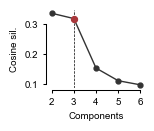

chosen k=3  rule=max_cophenetic  near-ties=[2, 3, 4]
Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/fig2/fig2_nmf_rank_k.svg


In [12]:
import json

rank = pd.read_csv(NMF_DIR / "rank_selection_metrics.csv")
chosen = json.loads((NMF_DIR / "chosen_k.json").read_text(encoding="utf-8"))
k_nmf = int(chosen["k"])
ks = sorted(rank["k"].astype(int).tolist())
y_star = float(rank.loc[rank["k"].eq(k_nmf), "silhouette_cosine"].iloc[0])

fig, ax = plt.subplots(figsize=(4 * cm, 4 * cm))
fig.subplots_adjust(bottom=0.38, top=0.88, left=0.32, right=0.94)

ax.plot(rank["k"], rank["silhouette_cosine"], "o-", color="0.2", lw=1, markersize=3.5)
ax.scatter([k_nmf], [y_star], s=18, color="#A9373B", zorder=3)
ax.axvline(k_nmf, color="k", linestyle="--", linewidth=0.5)
ax.set_xlabel("Components", fontsize=fontsize)
ax.set_ylabel("Cosine sil.", fontsize=fontsize)
ax.set_xticks(ks)
ax.tick_params(labelsize=fontsize, width=0.75, length=2, which="both")
plt.setp(ax.spines.values(), linewidth=0.75)
sns.despine(ax=ax, offset=1, trim=True)

save_aligned_svg(fig, "fig2_nmf_rank_k.svg")
plt.show()
print(f"chosen k={k_nmf}  rule={chosen['rule']}  near-ties={chosen['near_tie_ks']}")
print("Wrote", IMG_DIR / "fig2_nmf_rank_k.svg")

## 6. Waveform PCA, k-means *k*=3

Same figure as `img/nmf/waveform_pca_kmeans.svg` (from `notebooks/nmf_pc_clustering.ipynb`).

Reads stored PC scores (`pc_scores.csv`). Fits k-means at NMF *k*=3 in the
embedding PCs, Hungarian-matches cluster names onto NMF labels, and plots
PC1–PC2 with marginal histograms. Does **not** refit NMF or overwrite
`channel_assignments.csv`.


ARI  NMF vs k-means k=3: 0.749


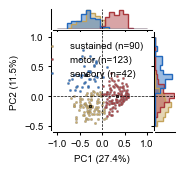

Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/fig2/fig2_waveform_pca_kmeans.svg


In [13]:
import json

from matplotlib.ticker import MultipleLocator
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

scores = pd.read_csv(NMF_DIR / "pc_scores.csv")
meta = json.loads((NMF_DIR / "pc_clustering_meta.json").read_text(encoding="utf-8"))
n_embed = int(meta["n_embedding_pcs"])
k_nmf = 3
rng = int(meta["random_state"])
explained = np.asarray(meta["explained_variance_ratio"], dtype=float)

embed = scores[[f"PC{i}" for i in range(1, n_embed + 1)]].to_numpy(float)
nmf = scores["functional_cluster"].astype(str)
km3 = KMeans(n_clusters=k_nmf, n_init=50, random_state=rng).fit_predict(embed)
nmf_names = ordered_clusters(nmf)
conf = pd.crosstab(pd.Series(km3), nmf).reindex(columns=nmf_names, fill_value=0)
rows, cols = linear_sum_assignment(-conf.to_numpy(float))
km3_to_name = {int(conf.index[r]): nmf_names[c] for r, c in zip(rows, cols)}
km3_named = np.array([km3_to_name[int(v)] for v in km3])

print(f"ARI  NMF vs k-means k={k_nmf}: {adjusted_rand_score(nmf, km3):.3f}")

x = scores["PC1"].to_numpy(float)
y = scores["PC2"].to_numpy(float)
x_bins = np.linspace(np.floor(x.min() / 0.5) * 0.5, np.ceil(x.max() / 0.5) * 0.5, 20)
y_bins = np.linspace(np.floor(y.min() / 0.5) * 0.5, np.ceil(y.max() / 0.5) * 0.5, 20)

fig = plt.figure(figsize=(4 * cm, 4 * cm))
grid = fig.add_gridspec(
    2,
    2,
    width_ratios=(5.0, 1),
    height_ratios=(1, 5.0),
    wspace=0.06,
    hspace=0.06,
)
ax_histx = fig.add_subplot(grid[0, 0])
ax = fig.add_subplot(grid[1, 0], sharex=ax_histx)
ax_histy = fig.add_subplot(grid[1, 1], sharey=ax)

for cluster in nmf_names:
    mask = km3_named == cluster
    color = FUNCTION_COLORS.get(cluster, "0.4")
    ax.scatter(
        x[mask],
        y[mask],
        s=3,
        color=color,
        edgecolor="gray",
        linewidth=0.2,
        alpha=0.9,
        label=f"{CLUSTER_LABELS.get(cluster, cluster)} (n={int(mask.sum())})",
    )
    ax.scatter(
        x[mask].mean(),
        y[mask].mean(),
        s=3,
        marker="X",
        color=color,
        edgecolor="black",
        linewidth=0.5,
        zorder=3,
    )
    ax_histx.hist(
        x[mask],
        bins=x_bins,
        density=True,
        histtype="stepfilled",
        color=color,
        alpha=0.45,
        linewidth=0,
    )
    ax_histx.hist(x[mask], bins=x_bins, density=True, histtype="step", color=color, linewidth=1)
    ax_histy.hist(
        y[mask],
        bins=y_bins,
        density=True,
        histtype="stepfilled",
        orientation="horizontal",
        color=color,
        alpha=0.45,
        linewidth=0,
    )
    ax_histy.hist(
        y[mask],
        bins=y_bins,
        density=True,
        histtype="step",
        orientation="horizontal",
        color=color,
        linewidth=1,
    )

ax.set_xlabel(f"PC1 ({100 * explained[0]:.1f}%)", fontsize=fontsize)
ax.set_ylabel(f"PC2 ({100 * explained[1]:.1f}%)", fontsize=fontsize)
ax.axhline(0.0, color="k", linestyle="--", linewidth=0.5)
ax.axvline(0.0, color="k", linestyle="--", linewidth=0.5)
ax_histx.axvline(0.0, color="k", linestyle="--", linewidth=0.5)
ax_histy.axhline(0.0, color="k", linestyle="--", linewidth=0.5)
for axis in (ax, ax_histx, ax_histy):
    axis.tick_params(labelsize=fontsize, width=0.75, length=2, which="both")
    plt.setp(axis.spines.values(), linewidth=0.75)
    sns.despine(ax=axis, offset=1, trim=False)
ax.xaxis.set_major_locator(MultipleLocator(0.5))
ax.yaxis.set_major_locator(MultipleLocator(0.5))
ax_histx.tick_params(labelbottom=False, labelleft=False, left=False)
ax_histx.set_yticks([])
ax_histy.tick_params(labelleft=False, labelbottom=False, bottom=False)
ax_histy.set_xticks([])
ax.legend(frameon=False, fontsize=fontsize, loc="best")

out = save_svg(fig, IMG_DIR / "fig2_waveform_pca_kmeans.svg")
plt.show()
print("Wrote", out)


## 6b. Dominance and mixed assignments

Stacked histogram of NMF **dominance** (`max(W) / sum(W)`) by hard label.
An electrode is **mixed** when winner minus runner-up loading proportion
is `< 0.20` (same cutoff as `functional_hga_specificity`). The dashed line
marks the equivalent two-way dominance (`0.60`). Mixed contacts stay in the
NMF hard-label results; they are only flagged here and on the spatial map.


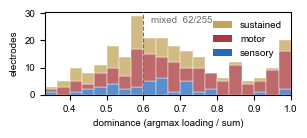

Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/fig2/fig2_nmf_dominance.svg
mixed (specificity_max < 0.2): 62 / 255 (24%)
functional_cluster
sustain    24
motor      24
sensory    14
Name: is_mixed, dtype: int64


In [14]:
from matplotlib.patches import Patch

assignments = annotate_mixed_assignments(assignments)
qc = assignments.loc[assignments["functional_cluster"].isin(CLUSTERS)].copy()
qc["cluster_label"] = qc["functional_cluster"].map(CLUSTER_LABELS)
n_mixed = int(qc["is_mixed"].sum())
n_all = len(qc)

fig, ax = plt.subplots(figsize=(8 * cm, 3 * cm))
sns.histplot(
    data=qc,
    x="dominance",
    hue="cluster_label",
    hue_order=HUE_ORDER,
    palette=PALETTE,
    multiple="stack",
    bins=20,
    binrange=(1 / 3, 1.0),
    ax=ax,
    legend=False,
    linewidth=0.3,
    edgecolor="white",
)
ax.axvline(MIXED_DOMINANCE_REF, color=MIXED_COLOR, lw=0.8, ls="--", zorder=3)
ax.set_xlim(1 / 3, 1.0)
ax.set_xlabel("dominance (argmax loading / sum)", **fontdict)
ax.set_ylabel("electrodes", **fontdict)
ax.tick_params(labelsize=fontsize)
ax.text(
    MIXED_DOMINANCE_REF + 0.02,
    0.95,
    f"mixed  {n_mixed}/{n_all}",
    transform=ax.get_xaxis_transform(),
    ha="left",
    va="top",
    fontsize=fontsize,
    color=MIXED_COLOR,
)
ax.legend(
    handles=[
        Patch(facecolor=FUNCTION_COLORS[c], edgecolor="none", label=CLUSTER_LABELS[c])
        for c in CLUSTERS
    ],
    frameon=False,
    fontsize=fontsize,
    loc="upper right",
)
fig.subplots_adjust(left=0.16, right=0.94, bottom=0.22, top=0.92)
out = save_svg(fig, IMG_DIR / "fig2_nmf_dominance.svg")
plt.show()
print("Wrote", out)
print(
    f"mixed (specificity_max < {MIXED_SPECIFICITY_MAX}): "
    f"{n_mixed} / {n_all} ({100 * n_mixed / n_all:.0f}%)"
)
print(qc.groupby("functional_cluster")["is_mixed"].sum().reindex(CLUSTERS).astype(int))


## 7. Insula spatial map (static)

Only the insula is drawn: whole-brain cortex is hidden (`alpha=0`), then the
insula faces from `aparc.a2009s` are added as a mesh in the same pale gray as
`functional_hga` (`(0.9, 0.9, 0.9)`, alpha `0.55`). Equal-size spheres colored
by NMF hard labels, plus KDE contour envelopes. Island contours around a single
electrode are dropped (`KDE_MIN_POINTS`); the point itself stays. Does **not**
encode HGA or split by phase. The screenshot is cropped to the insula; cluster
*n* is in the legend.

Renders in this notebook (no Slurm). Tune `KDE_BANDWIDTH_PX` / `KDE_LEVEL_FRAC`.


Using notebook 3d backend.
Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/rh.aparc.a2009s.annot


2026-09-19 17:22:33.165 (   7.577s) [    7FD97547E740]vtkXOpenGLRenderWindow.:1416  WARN| bad X server connection. DISPLAY=


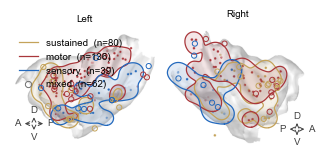

Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/fig2/fig2_insula_spatial_kdecontour.svg
functional_cluster
sustain     80
motor      136
sensory     39
mixed on map: 62 / 255 (specificity_max < 0.2)


In [15]:
import os
import warnings

import mne
import pyvista as pv
from matplotlib.lines import Line2D
from matplotlib.path import Path as MplPath
from mne.viz import Brain
from scipy.ndimage import gaussian_filter
from scipy.spatial import cKDTree

os.environ.setdefault("PYVISTA_OFF_SCREEN", "true")
pv.OFF_SCREEN = True
mne.viz.set_3d_backend("notebook")

recon_dir = "/cwork/ns458/ECoG_Recon/"
template = "cvs_avg35_inMNI152"
insula_patterns = (
    "G_insular_short",
    "G_Ins_lg_and_S_cent_ins",
    "S_circular_insula_ant",
    "S_circular_insula_inf",
    "S_circular_insula_sup",
)
POINT_SIZE = 10.0
KDE_BANDWIDTH_PX = 25.0
KDE_LEVEL_FRAC = 0.18
KDE_FILL_ALPHA = 0.12
KDE_MIN_POINTS = 2
CROP_PAD_PX = 24
INSULA_COLOR = (0.9, 0.9, 0.9)
INSULA_LABEL_ALPHA = 0.55

labels = mne.read_labels_from_annot(
    subject=template,
    parc="aparc.a2009s",
    surf_name="pial",
    hemi="both",
    subjects_dir=recon_dir,
)
lh_pial_coords, lh_faces = mne.read_surface(f"{recon_dir}/{template}/surf/lh.pial")
rh_pial_coords, rh_faces = mne.read_surface(f"{recon_dir}/{template}/surf/rh.pial")
lh_tree = cKDTree(lh_pial_coords)
rh_tree = cKDTree(rh_pial_coords)


def _insula_vertices(hemi: str) -> np.ndarray:
    verts = []
    for lab in labels:
        if lab.hemi == hemi and any(p in lab.name for p in insula_patterns):
            verts.extend(lab.vertices)
    if not verts:
        raise RuntimeError(f"No insula labels for {hemi}")
    return np.unique(verts)


def _faces_to_polydata(coords, faces) -> pv.PolyData:
    faces_pv = np.hstack(
        [np.full((len(faces), 1), 3, dtype=np.int64), np.asarray(faces, dtype=np.int64)]
    ).ravel()
    return pv.PolyData(np.asarray(coords, dtype=float), faces_pv)


def insula_mesh(hemi: str, pial: np.ndarray, faces: np.ndarray):
    verts = _insula_vertices(hemi)
    keep = np.all(np.isin(faces, verts), axis=1)
    mesh = _faces_to_polydata(pial, faces[keep])
    center = pial[verts].mean(axis=0)
    return mesh, center


lh_insula, lh_insula_center = insula_mesh("lh", lh_pial_coords, lh_faces)
rh_insula, rh_insula_center = insula_mesh("rh", rh_pial_coords, rh_faces)


def snap_to_pial(coords, tree, pial):
    _, idx = tree.query(coords)
    return pial[idx]


def add_cluster_spheres(brain, coords, clusters, tree, pial, keep_mask=None):
    coords = np.asarray(coords, dtype=float)
    if coords.size == 0:
        return np.zeros((0, 3), dtype=float)
    snapped = snap_to_pial(coords, tree, pial)
    if keep_mask is None:
        keep_mask = np.ones(len(coords), dtype=bool)
    keep_mask = np.asarray(keep_mask, dtype=bool)
    for cluster in CLUSTERS:
        mask = (np.asarray(clusters) == cluster) & keep_mask
        if not mask.any():
            continue
        cloud = pv.PolyData(np.asarray(snapped[mask], dtype=float))
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=POINT_SIZE,
            color=FUNCTION_COLORS[cluster],
            lighting=False,
        )
    return snapped


def project_xy(plotter, points, image_shape):
    pts = np.asarray(points, dtype=float)
    if pts.size == 0:
        return np.zeros((0, 2), dtype=float)
    if hasattr(plotter, "project_points_to_pixels"):
        pix = np.asarray(plotter.project_points_to_pixels(pts), dtype=float)
        xy = np.asarray(pix[:, :2], dtype=float)
    else:
        import vtk

        renderer = plotter.renderer
        coordinate = vtk.vtkCoordinate()
        coordinate.SetCoordinateSystemToWorld()
        xy = np.zeros((len(pts), 2), dtype=float)
        for i, (x, y, z) in enumerate(pts):
            coordinate.SetValue(float(x), float(y), float(z))
            d = coordinate.GetComputedDisplayValue(renderer)
            xy[i] = (float(d[0]), float(d[1]))
    h = int(image_shape[0])
    xy[:, 1] = (h - 1) - xy[:, 1]
    return xy


def _keep_ring(ring, pts) -> bool:
    """Drop island contours that wrap fewer than KDE_MIN_POINTS electrodes."""
    if len(pts) < KDE_MIN_POINTS:
        return False
    return int(MplPath(np.asarray(ring, dtype=float)).contains_points(pts).sum()) >= KDE_MIN_POINTS


def kde_contour_rings(xy, image_shape, *, bandwidth_px=KDE_BANDWIDTH_PX, level_frac=KDE_LEVEL_FRAC):
    pts = np.asarray(xy, dtype=float)
    if len(pts) < 3:
        return []
    h, w = int(image_shape[0]), int(image_shape[1])
    dens = np.zeros((h, w), dtype=float)
    xs = np.clip(np.round(pts[:, 0]).astype(int), 0, w - 1)
    ys = np.clip(np.round(pts[:, 1]).astype(int), 0, h - 1)
    for x, y in zip(xs, ys):
        dens[y, x] += 1.0
    dens = gaussian_filter(dens, sigma=float(bandwidth_px))
    peak = float(dens.max())
    if peak <= 0:
        return []
    level = peak * float(level_frac)
    try:
        from skimage.measure import find_contours

        contours = find_contours(dens, level=level)
        rings = []
        for cont in contours:
            if len(cont) < 8:
                continue
            ring = np.column_stack([cont[:, 1], cont[:, 0]])
            ring = np.vstack([ring, ring[0]])
            if _keep_ring(ring, pts):
                rings.append(ring)
        return rings
    except ImportError:
        fig_c, ax_c = plt.subplots()
        yy, xx = np.mgrid[0:h, 0:w]
        cs = ax_c.contour(xx, yy, dens, levels=[level])
        rings = []
        for segs in cs.allsegs:
            for seg in segs:
                if len(seg) < 8:
                    continue
                ring = np.vstack([seg, seg[0]])
                if _keep_ring(ring, pts):
                    rings.append(ring)
        plt.close(fig_c)
        return rings


def draw_rings(ax, rings, color):
    for ring in rings:
        ax.fill(ring[:, 0], ring[:, 1], color=color, alpha=KDE_FILL_ALPHA, linewidth=0, zorder=3)
        ax.plot(
            ring[:, 0],
            ring[:, 1],
            color=color,
            linewidth=0.9,
            solid_capstyle="round",
            solid_joinstyle="round",
            zorder=4,
        )


def draw_ap_dv(ax, *, anterior_is_left: bool, corner: str):
    """A–P / D–V orientation cross in axes-fraction coordinates."""
    if corner == "lower left":
        x0, y0, arm = 0.16, 0.18, 0.08
    else:
        # Further into the outer white corner so P does not meet the mesh.
        x0, y0, arm = 0.91, 0.16, 0.07
    gap = 0.012
    if anterior_is_left:
        tips = {"A": (x0 - arm, y0), "P": (x0 + arm, y0), "D": (x0, y0 + arm), "V": (x0, y0 - arm)}
    else:
        tips = {"A": (x0 + arm, y0), "P": (x0 - arm, y0), "D": (x0, y0 + arm), "V": (x0, y0 - arm)}
    for label, (tx, ty) in tips.items():
        sx = x0 + gap * np.sign(tx - x0) if tx != x0 else x0
        sy = y0 + gap * np.sign(ty - y0) if ty != y0 else y0
        ax.annotate(
            "",
            xy=(tx, ty),
            xytext=(sx, sy),
            xycoords="axes fraction",
            textcoords="axes fraction",
            arrowprops=dict(arrowstyle="->", color="0.25", lw=0.7, mutation_scale=7),
            annotation_clip=False,
        )
        px = 0.03 * np.sign(tx - x0) if tx != x0 else 0.0
        py = 0.035 * np.sign(ty - y0) if ty != y0 else 0.0
        ax.text(
            tx + px,
            ty + py,
            label,
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=fontsize,
            color="0.25",
            clip_on=False,
        )


def crop_to_content(img, xy, pad=CROP_PAD_PX):
    rgb = np.asarray(img)
    mask = np.any(rgb < 250, axis=2)
    if not mask.any():
        return rgb, np.asarray(xy, dtype=float)
    ys, xs = np.nonzero(mask)
    y0 = max(0, int(ys.min()) - pad)
    y1 = min(rgb.shape[0], int(ys.max()) + 1 + pad)
    x0 = max(0, int(xs.min()) - pad)
    x1 = min(rgb.shape[1], int(xs.max()) + 1 + pad)
    xy_c = np.asarray(xy, dtype=float).copy()
    if xy_c.size:
        xy_c[:, 0] -= x0
        xy_c[:, 1] -= y0
    return rgb[y0:y1, x0:x1], xy_c


def render_hemi(hemi: str, coords, clusters, sphere_mask=None):
    brain = Brain(
        template,
        subjects_dir=recon_dir,
        surf="pial",
        hemi=hemi,
        background="white",
        show=False,
        cortex=INSULA_COLOR,
        alpha=0.0,
        size=(800, 800),
    )
    plotter = brain._renderer.plotter
    mesh = lh_insula if hemi == "lh" else rh_insula
    plotter.add_mesh(
        mesh,
        color=INSULA_COLOR,
        opacity=INSULA_LABEL_ALPHA,
        lighting=True,
        smooth_shading=True,
    )
    tree = lh_tree if hemi == "lh" else rh_tree
    pial = lh_pial_coords if hemi == "lh" else rh_pial_coords
    snapped = add_cluster_spheres(
        brain, coords, clusters, tree, pial, keep_mask=sphere_mask
    )
    center = lh_insula_center if hemi == "lh" else rh_insula_center
    az = 180 if hemi == "lh" else 0
    brain.show_view(azimuth=az, elevation=90, distance=180, focalpoint=center)
    for _ in range(3):
        plotter.render()
    img = np.asarray(brain.screenshot(mode="rgb"))
    xy = project_xy(plotter, snapped, img.shape[:2])
    brain.close()
    return img, xy


if "is_mixed" not in assignments.columns:
    assignments = annotate_mixed_assignments(assignments)

spatial = assignments.loc[
    assignments["functional_cluster"].isin(CLUSTERS)
    & ~assignments["subject"].isin(EXCLUDE_SUBJECTS)
    & assignments[["x", "y", "z"]].notna().all(axis=1)
].copy()
cord = spatial[["x", "y", "z"]].to_numpy(float)
clust = spatial["functional_cluster"].to_numpy()
mixed = spatial["is_mixed"].to_numpy(dtype=bool)
mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    lh_img, lh_xy = render_hemi(
        "lh", cord[mask_lh], clust[mask_lh], sphere_mask=~mixed[mask_lh]
    )
    rh_img, rh_xy = render_hemi(
        "rh", cord[mask_rh], clust[mask_rh], sphere_mask=~mixed[mask_rh]
    )

lh_img, lh_xy = crop_to_content(lh_img, lh_xy)
rh_img, rh_xy = crop_to_content(rh_img, rh_xy)
bw_px = KDE_BANDWIDTH_PX  # crop after render; keep the 800-px KDE scale

fig, axes = plt.subplots(1, 2, figsize=(8 * cm , 3.5 * cm))
for ax, img, xy, clusters_hemi, mixed_hemi, title in (
    (axes[0], lh_img, lh_xy, clust[mask_lh], mixed[mask_lh], "Left"),
    (axes[1], rh_img, rh_xy, clust[mask_rh], mixed[mask_rh], "Right"),
):
    ax.imshow(img)
    ax.set_xlim(0, img.shape[1])
    ax.set_ylim(img.shape[0], 0)
    ax.axis("off")
    ax.set_title(title, fontsize=fontsize)
    in_frame = (
        (xy[:, 0] >= 0)
        & (xy[:, 0] < img.shape[1])
        & (xy[:, 1] >= 0)
        & (xy[:, 1] < img.shape[0])
    )
    mixed_hemi = np.asarray(mixed_hemi, dtype=bool)
    for cluster in CLUSTERS:
        pts = xy[
            in_frame
            & (np.asarray(clusters_hemi) == cluster)
            & ~mixed_hemi
        ]
        draw_rings(
            ax,
            kde_contour_rings(pts, img.shape[:2], bandwidth_px=bw_px),
            FUNCTION_COLORS[cluster],
        )
    mixed_pts = xy[in_frame & mixed_hemi]
    mixed_clust = np.asarray(clusters_hemi)[in_frame & mixed_hemi]
    if len(mixed_pts):
        ax.scatter(
            mixed_pts[:, 0],
            mixed_pts[:, 1],
            s=14,
            facecolors="none",
            edgecolors=[FUNCTION_COLORS[c] for c in mixed_clust],
            linewidths=0.7,
            zorder=5,
        )
    if title == "Left":
        draw_ap_dv(ax, anterior_is_left=True, corner="lower left")
    else:
        draw_ap_dv(ax, anterior_is_left=False, corner="lower right")

n_by_cluster = spatial.groupby("functional_cluster")["channel"].nunique()
n_mixed_map = int(spatial["is_mixed"].sum())
axes[0].legend(
    handles=[
        Line2D(
            [0],
            [0],
            color=FUNCTION_COLORS[c],
            linewidth=0.9,
            label=f"{CLUSTER_LABELS[c]}  (n={int(n_by_cluster.get(c, 0))})",
        )
        for c in CLUSTERS
    ]
    + [
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor="none",
            markeredgecolor=MIXED_COLOR,
            markeredgewidth=0.7,
            markersize=4.5,
            label=f"mixed  (n={n_mixed_map})",
        )
    ],
    frameon=False,
    fontsize=fontsize,
    loc="upper left",
)
fig.subplots_adjust(wspace=0.02, left=0.02, right=0.98, top=0.92, bottom=0.02)
out = save_svg(fig, IMG_DIR / "fig2_insula_spatial_kdecontour.svg")
plt.show()
print("Wrote", out)
print(n_by_cluster.reindex(CLUSTERS).to_string())
print(
    f"mixed on map: {n_mixed_map} / {len(spatial)} "
    f"(specificity_max < {MIXED_SPECIFICITY_MAX})"
)


## 8. Cluster × Hammers pies

One pie per cluster: **ant. short** (ASG), **int. short** (pole + MSG + PSG),
**long gyri** (ALG + PLG). Hammers labels from packaged HGA, not Destrieux.
Pies only — add leader lines in Illustrator if needed.


Hammers-labeled channels: 254 / 255 (assigned n=255)
group               ASG  intermediate  long
functional_cluster                         
sustain              30            34    15
motor                22            69    45
sensory               1             9    29
n pie / n assigned
                    pie  assigned
functional_cluster               
sustain              79        80
motor               136       136
sensory              39        39


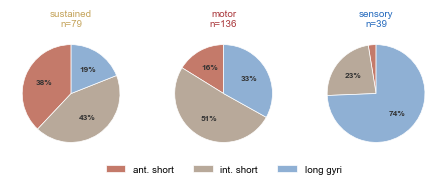

Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/fig2/fig2_insula_cluster_parcel_pies.svg


In [16]:
from matplotlib.patches import Patch

from src.connectivity.pairwise.seeds import hammers_insula_subregion

GROUP_ORDER = ["ASG", "intermediate", "long"]
GROUP_LABELS = {
    "ASG": "ant. short",
    "intermediate": "int. short",
    "long": "long gyri",
}
GROUP_COLORS = {
    "ASG": "#C47A6A",
    "intermediate": "#B8A99A",
    "long": "#8FB0D4",
}
SUBREGION_TO_GROUP = {
    "ASG": "ASG",
    "AP": "intermediate",
    "MSG": "intermediate",
    "PSG": "intermediate",
    "ALG": "long",
    "PLG": "long",
}


def _label_mode(series):
    modes = series.mode()
    return modes.iloc[0] if len(modes) else series.iloc[0]


def hammers_label_by_channel(channels):
    """Hammers gyrus labels for NMF channels. Prefer in-memory subset, else one HGA file per subject."""
    wanted = set(channels)
    src = None
    if "subset" in globals() and isinstance(subset, pd.DataFrame) and "label" in subset.columns:
        src = subset.loc[subset["channel"].isin(wanted), ["channel", "label"]].dropna()
        src = src[~src["label"].astype(str).isin(["0", "nan", ""])]
    if src is None or src["channel"].nunique() < 0.5 * len(wanted):
        wanted_subjects = {str(ch).split("_", 1)[0] for ch in wanted}
        found = {}
        hga_root = hga_results_dir(TASKS[0]).parent
        for sub in sorted(wanted_subjects):
            matches = sorted(hga_root.glob(f"*/sub-{sub}/HGA/*_time.csv"))
            if matches:
                found[sub] = matches[0]
        frames = []
        for path in found.values():
            df = pd.read_csv(path, usecols=["channel", "label"])
            df = df[df["channel"].isin(wanted)]
            frames.append(df)
        src = (
            pd.concat(frames, ignore_index=True)
            if frames
            else pd.DataFrame(columns=["channel", "label"])
        )
        src = src.dropna(subset=["channel", "label"])
        src = src[~src["label"].astype(str).isin(["0", "nan", ""])]
    if src.empty:
        raise RuntimeError("No Hammers labels found for assigned channels.")
    return src.groupby("channel")["label"].agg(_label_mode)


parcel_df = assignments.loc[
    assignments["functional_cluster"].isin(CLUSTERS)
    & ~assignments["subject"].isin(EXCLUDE_SUBJECTS),
    ["channel", "functional_cluster"],
].drop_duplicates("channel").copy()
parcel_df["label"] = parcel_df["channel"].map(hammers_label_by_channel(parcel_df["channel"]))
parcel_df["subregion"] = parcel_df["label"].map(hammers_insula_subregion)
parcel_df["group"] = parcel_df["subregion"].map(SUBREGION_TO_GROUP)
parcel_ok = parcel_df.dropna(subset=["group"]).copy()

ct = (
    parcel_ok.groupby(["functional_cluster", "group"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=CLUSTERS, columns=GROUP_ORDER, fill_value=0)
    .astype(int)
)
n_labeled = parcel_ok.groupby("functional_cluster")["channel"].nunique()
n_assigned = parcel_df.groupby("functional_cluster")["channel"].nunique()
print(
    f"Hammers-labeled channels: {len(parcel_ok)} / {len(parcel_df)} "
    f"(assigned n={int(n_assigned.sum())})"
)
print(ct.to_string())
print("n pie / n assigned")
print(
    pd.DataFrame({"pie": n_labeled, "assigned": n_assigned})
    .reindex(CLUSTERS)
    .fillna(0)
    .astype(int)
    .to_string()
)


def _style_pie_autotexts(autotexts):
    for text in autotexts:
        text.set_color("0.2")
        text.set_fontweight("bold")
        text.set_fontsize(6)


fig, axes = plt.subplots(1, len(CLUSTERS), figsize=(FIG2_WIDTH, 4.2 * cm))
for ax, cluster in zip(axes, CLUSTERS):
    sizes = np.asarray([int(ct.loc[cluster, g]) for g in GROUP_ORDER], dtype=int)
    keep = sizes > 0
    if not keep.any():
        ax.axis("off")
        continue
    _, _, autotexts = ax.pie(
        sizes[keep],
        labels=None,
        colors=[GROUP_COLORS[g] for g, on in zip(GROUP_ORDER, keep) if on],
        autopct=lambda pct: f"{pct:.0f}%" if pct >= 8 else "",
        startangle=90,
        textprops={"fontsize": fontsize},
        wedgeprops={"linewidth": 0.5, "edgecolor": "white"},
    )
    _style_pie_autotexts(autotexts)
    ax.set_title(
        f"{CLUSTER_LABELS[cluster]}\nn={int(sizes.sum())}",
        fontsize=fontsize,
        color=FUNCTION_COLORS[cluster],
        pad=4,
    )

fig.legend(
    handles=[
        Patch(
            facecolor=GROUP_COLORS[g],
            edgecolor="white",
            linewidth=0.5,
            label=GROUP_LABELS[g],
        )
        for g in GROUP_ORDER
    ],
    frameon=False,
    fontsize=fontsize,
    loc="lower center",
    ncol=len(GROUP_ORDER),
    bbox_to_anchor=(0.5, -0.08),
)
fig.tight_layout()
out = save_svg(fig, IMG_DIR / "fig2_insula_cluster_parcel_pies.svg")
plt.show()
print("Wrote", out)


## 8b. Six Hammers gyri pies (comparison)

Same electrodes as cell 8, but one wedge per gyrus, anterior → posterior:
AP, ASG, MSG, PSG, ALG, PLG. Cluster gold/red/blue stay on the titles.

Anatomical fill: set `GYRUS_PALETTE` to `purples` (default), `teal`, or `split`
(short gyri teal, long gyri plum).


subregion           AP  ASG  MSG  PSG  ALG  PLG
functional_cluster                             
sustain             19   30    6    9    4   11
motor               12   22   23   34   32   13
sensory              5    1    0    4    9   20
n by cluster: {'sustain': 79, 'motor': 136, 'sensory': 39}


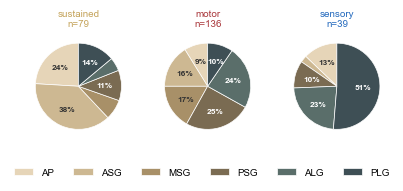

Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/fig2/fig2_insula_cluster_parcel_pies_k6.svg


In [17]:
from matplotlib.patches import Patch

from src.connectivity.pairwise.seeds import hammers_insula_subregion

GYRUS_ORDER = ["AP", "ASG", "MSG", "PSG", "ALG", "PLG"]
GYRUS_LABELS = {g: g for g in GYRUS_ORDER}
# Anterior (sand) → posterior (slate). Avoid cluster gold / red / blue.
GYRUS_COLORS = {
    "AP": "#E6D5B8",
    "ASG": "#CDB892",
    "MSG": "#A89068",
    "PSG": "#7A6B52",
    "ALG": "#5A6E6A",
    "PLG": "#3E4F55",
}


def _hex_luminance(hex_color: str) -> float:
    h = hex_color.lstrip("#")
    r, g, b = (int(h[i : i + 2], 16) / 255 for i in (0, 2, 4))
    return 0.2126 * r + 0.7152 * g + 0.0722 * b


if "parcel_ok" in globals() and "subregion" in parcel_ok.columns:
    parcel_k6 = parcel_ok.dropna(subset=["subregion"]).copy()
else:
    if "hammers_label_by_channel" not in globals():
        raise RuntimeError("Run the three-wedge pie cell first, or define hammers_label_by_channel.")
    parcel_k6 = assignments.loc[
        assignments["functional_cluster"].isin(CLUSTERS)
        & ~assignments["subject"].isin(EXCLUDE_SUBJECTS),
        ["channel", "functional_cluster"],
    ].drop_duplicates("channel").copy()
    parcel_k6["label"] = parcel_k6["channel"].map(
        hammers_label_by_channel(parcel_k6["channel"])
    )
    parcel_k6["subregion"] = parcel_k6["label"].map(hammers_insula_subregion)
    parcel_k6 = parcel_k6.dropna(subset=["subregion"]).copy()

ct6 = (
    parcel_k6.groupby(["functional_cluster", "subregion"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=CLUSTERS, columns=GYRUS_ORDER, fill_value=0)
    .astype(int)
)
print(ct6.to_string())
print("n by cluster:", ct6.sum(axis=1).to_dict())


def _style_pie_autotexts_k6(autotexts, colors):
    for text, color in zip(autotexts, colors):
        text.set_color("white" if _hex_luminance(color) < 0.45 else "0.2")
        text.set_fontweight("bold")
        text.set_fontsize(6)


fig, axes = plt.subplots(1, len(CLUSTERS), figsize=(FIG2_WIDTH, 4.4 * cm))
for ax, cluster in zip(axes, CLUSTERS):
    sizes = np.asarray([int(ct6.loc[cluster, g]) for g in GYRUS_ORDER], dtype=int)
    keep = sizes > 0
    if not keep.any():
        ax.axis("off")
        continue
    colors = [GYRUS_COLORS[g] for g, on in zip(GYRUS_ORDER, keep) if on]
    _, _, autotexts = ax.pie(
        sizes[keep],
        labels=None,
        colors=colors,
        autopct=lambda pct: f"{pct:.0f}%" if pct >= 8 else "",
        startangle=90,
        textprops={"fontsize": fontsize},
        wedgeprops={"linewidth": 0.5, "edgecolor": "white"},
    )
    _style_pie_autotexts_k6(autotexts, colors)
    ax.set_title(
        f"{CLUSTER_LABELS[cluster]}\nn={int(sizes.sum())}",
        fontsize=fontsize,
        color=FUNCTION_COLORS[cluster],
        pad=4,
    )

fig.legend(
    handles=[
        Patch(
            facecolor=GYRUS_COLORS[g],
            edgecolor="white",
            linewidth=0.5,
            label=GYRUS_LABELS[g],
        )
        for g in GYRUS_ORDER
    ],
    frameon=False,
    fontsize=fontsize,
    loc="lower center",
    ncol=len(GYRUS_ORDER),
    bbox_to_anchor=(0.5, -0.08),
)
out = save_svg(fig, IMG_DIR / "fig2_insula_cluster_parcel_pies_k6.svg")
plt.show()
print("Wrote", out)

## 9. Laterality: implant-corrected cluster rate

Left coverage is heavier, so raw L/R counts are not laterality. Each line is
cluster rate: assigned *n* / implanted pure AIC/PIC in that hemisphere. Parallel
≈ same composition after correcting sampling; a slope would be a true
hemispheric bias.

Per-cluster **Fisher exact** tests assigned vs not-assigned × Left vs Right
(H0: rate_L = rate_R). A 3×2 **χ²** tests whether cluster mix differs by
hemisphere. Not a physiology LI.


implanted AIC/PIC  L=281  R=179
assigned n
hemi                 L   R
functional_cluster        
sustain             49  31
motor               84  52
sensory             24  15
rate = assigned / implanted
hemi                    L      R
functional_cluster              
sustain             0.174  0.173
motor               0.299  0.291
sensory             0.085  0.084
Fisher exact  assigned vs not × L vs R
  sustained   p=1.00
  motor       p=0.92
  sensory     p=1.00
χ² cluster × hemi  p=1.00


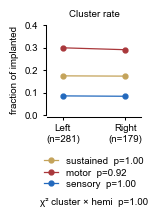

Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/fig2/fig2_laterality_cluster_rate.svg


In [18]:
import pathlib

from scipy.stats import chi2_contingency, fisher_exact

from src.connectivity.pairwise.config import DEFAULT_DATASETS
from src.nmf.waveform_pca import load_exclude_channels
from src.paths import nmf_exclude_channels_path


def _as_bool_mix(values: pd.Series) -> pd.Series:
    if values.dtype == bool:
        return values
    text = values.astype(str).str.strip().str.lower()
    return text.isin({"1", "true", "t", "yes"})


def load_implanted_insula() -> pd.DataFrame:
    """Unique pure AIC/PIC bipolar contacts across the four NMF tasks."""
    frames = []
    for task, bids_root in DEFAULT_DATASETS.items():
        if task == "LexicalNoDelay":
            continue
        root = pathlib.Path(bids_root)
        paths = sorted(root.glob("derivatives/parcellation/sub-*/bipolar/sub-*_hammers.csv"))
        for path in paths:
            df = pd.read_csv(path, usecols=lambda c: c in {"name", "roi", "hemi", "mix"})
            if not {"name", "roi", "hemi"}.issubset(df.columns):
                continue
            df = df.copy()
            df["subject"] = path.parent.parent.name.removeprefix("sub-")
            df["channel"] = df["name"].astype(str)
            frames.append(df)
    if not frames:
        raise FileNotFoundError("No Hammers parcellation CSVs in DEFAULT_DATASETS")
    allc = pd.concat(frames, ignore_index=True)
    if "mix" in allc.columns:
        allc["mix"] = _as_bool_mix(allc["mix"].fillna(False))
    else:
        allc["mix"] = False
    allc["hemi"] = allc["hemi"].astype(str).str.upper().str[0]
    uniq = allc.drop_duplicates(["subject", "channel"], keep="first")
    uniq = uniq[~uniq["subject"].isin(EXCLUDE_SUBJECTS)]
    implanted = uniq[uniq["roi"].astype(str).isin({"AIC", "PIC"}) & ~uniq["mix"]].copy()
    return implanted[implanted["hemi"].isin(["L", "R"])].reset_index(drop=True)


drop = load_exclude_channels(nmf_exclude_channels_path())
assign_lr = assignments.copy()
assign_lr["channel"] = assign_lr["channel"].astype(str)
assign_lr = assign_lr[~assign_lr["channel"].isin(drop)]
assign_lr = assign_lr[~assign_lr["subject"].astype(str).isin(EXCLUDE_SUBJECTS)]
assign_lr["hemi"] = assign_lr["hemi"].astype(str).str.upper().str[0]
assign_lr = assign_lr[assign_lr["hemi"].isin(["L", "R"])]
assign_lr = assign_lr[assign_lr["functional_cluster"].isin(CLUSTERS)]

implanted = load_implanted_insula()
n_imp = implanted.groupby("hemi").size()
n_cluster = (
    assign_lr.groupby(["functional_cluster", "hemi"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=CLUSTERS, columns=["L", "R"], fill_value=0)
)
n_rate = n_cluster.div(n_imp, axis=1)

n_imp_l = int(n_imp["L"])
n_imp_r = int(n_imp["R"])


def _fmt_p(p: float) -> str:
    if p < 0.001:
        return "p<0.001"
    return f"p={p:.2f}"


fisher_p = {}
for cluster in CLUSTERS:
    n_l = int(n_cluster.loc[cluster, "L"])
    n_r = int(n_cluster.loc[cluster, "R"])
    table = [
        [n_l, n_r],
        [n_imp_l - n_l, n_imp_r - n_r],
    ]
    _, fisher_p[cluster] = fisher_exact(table, alternative="two-sided")
_, p_chi, _, _ = chi2_contingency(n_cluster.to_numpy())

print(f"implanted AIC/PIC  L={n_imp_l}  R={n_imp_r}")
print("assigned n")
print(n_cluster.to_string())
print("rate = assigned / implanted")
print(n_rate.round(3).to_string())
print("Fisher exact  assigned vs not × L vs R")
for cluster in CLUSTERS:
    print(f"  {CLUSTER_LABELS[cluster]:10s}  {_fmt_p(fisher_p[cluster])}")
print(f"χ² cluster × hemi  {_fmt_p(p_chi)}")

fig, ax = plt.subplots(figsize=(3.6 * cm, 5.2 * cm))
x = np.array([0.0, 1.0])
for cluster in CLUSTERS:
    color = FUNCTION_COLORS[cluster]
    label = CLUSTER_LABELS[cluster]
    y_l = float(n_rate.loc[cluster, "L"])
    y_r = float(n_rate.loc[cluster, "R"])
    ax.plot(
        x,
        [y_l, y_r],
        "-o",
        color=color,
        ms=3.5,
        lw=0.9,
        label=f"{label}  {_fmt_p(fisher_p[cluster])}",
    )

ax.set_ylabel("fraction of implanted", fontsize=fontsize)
ax.set_title("Cluster rate", fontsize=fontsize)
hemi_tick = [
    f"Left\n(n={n_imp_l})",
    f"Right\n(n={n_imp_r})",
]
ax.set_xticks(x)
ax.set_xticklabels(hemi_tick)
ax.set_xlim(-0.25, 1.25)
ax.set_ylim(0, max(0.4, float(n_rate.to_numpy().max()) * 1.2))
ax.tick_params(labelsize=fontsize, width=0.75, length=2, which="both")
plt.setp(ax.spines.values(), linewidth=0.75)
sns.despine(ax=ax, offset=1, trim=False)
ax.legend(
    frameon=False,
    fontsize=fontsize,
    loc="upper center",
    ncol=1,
    bbox_to_anchor=(0.5, -0.42),
    handlelength=1.4,
    borderaxespad=0.0,
    labelspacing=0.25,
)
ax.text(
    0.5,
    -0.92,
    f"χ² cluster × hemi  {_fmt_p(p_chi)}",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=fontsize,
    clip_on=False,
)
fig.subplots_adjust(left=0.30, right=0.96, bottom=0.46, top=0.90)
out = save_svg(fig, IMG_DIR / "fig2_laterality_cluster_rate.svg")
plt.show()
print("Wrote", out)